In [1]:
import numpy as np
import scipy as sp
from scipy.special import factorial2 # needed for expansions of the spherical bessel functions near zero
from numpy import log, cosh, sinh, sqrt, zeros, linspace, ones, exp, argmin, pi, sin, cos
import matplotlib.pyplot as plt
from matplotlib.pyplot import gca
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn, factorial
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')
from utils import e_r_cpa_denominator, graphene_conductivity

### In the below, we examine the graphene coated sphere including coupling to free-space radiation

In [8]:
Rs = np.linspace(2, 256, 255)
epsilon_F = 0.4 # Fermi energy 
alpha = 1/137 # fine structure constant
epsilon_1 = 1
epsilon_2 = 1 # dielectric functions of the sphere interior and of the environment, respectively

In [9]:
non_retarded_dispersions = zeros((5, (len(Rs))))
for (i, l) in enumerate(range(1, 6)):
    non_retarded_dispersions[i, :] = sqrt(l*(l+1)*alpha*800*epsilon_F/(l*epsilon_1+(l+1)*epsilon_2)/Rs)/epsilon_F; #Intraband only approximation

In [10]:
M = 10000
N = 500
hbar_omegas_retarded = linspace(0.001, epsilon_F*5, M)
Rs_retarded = np.linspace(2, 256, N)
retarded_dispersions =  zeros((5, (len(Rs_retarded))))

hbar_omegas_retarded_reshaped = hbar_omegas_retarded.reshape((M, 1)).repeat(N, 1)
Rs_retarded_reshaped = Rs_retarded.reshape((1, N)).repeat(M, 0)

x0 = Rs_retarded_reshaped*hbar_omegas_retarded_reshaped/200
x2 = x0*sqrt(epsilon_2)
x1 = x0*sqrt(epsilon_1)
g_omega = (200j/(hbar_omegas_retarded_reshaped*Rs_retarded_reshaped))*graphene_conductivity(epsilon_F, hbar_omegas_retarded_reshaped, 0, include_interband=False)
for (i, l) in enumerate(range(1, 6)):
    tm_denominator = e_r_cpa_denominator(l, x0, epsilon_1, g_omega)
    retarded_dispersions[i, :] = hbar_omegas_retarded[log(np.abs(tm_denominator)).argmin(axis=0)]/epsilon_F

In [11]:
hbar = 6.67*1e-16 #hbar in eV*seconds
c = 3*1e17 # speed of light in nanometers per second 

kR_retarded = (retarded_dispersions*epsilon_F)*Rs_retarded/(hbar*c)
kR_non_retarded = (non_retarded_dispersions*epsilon_F)*Rs/(hbar*c)

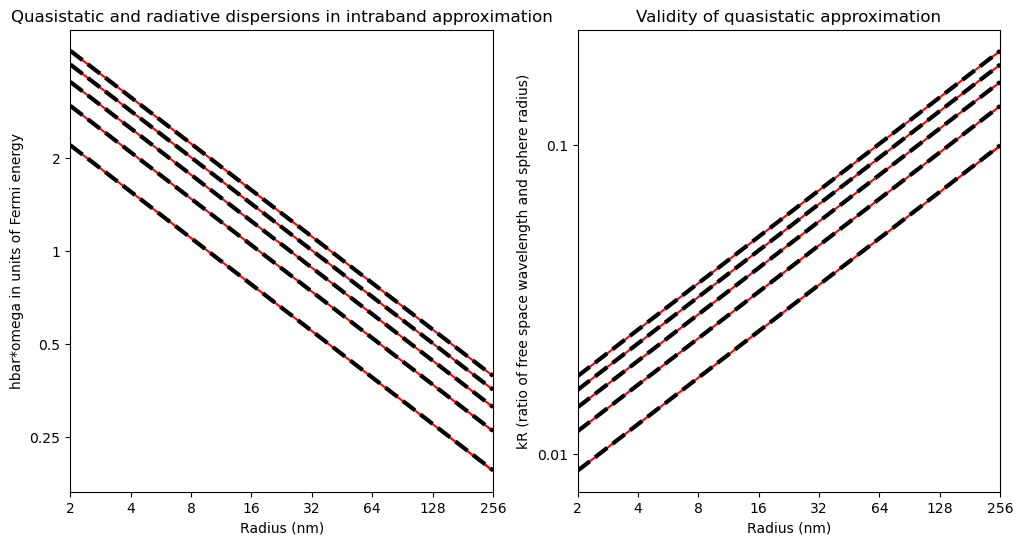

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for i in range(0, 5):
    ax1.plot(log(Rs_retarded), log(retarded_dispersions[i, :]), color="red", linestyle="solid", label=f"With radiative corrections, l={i+1}")
    ax1.plot(log(Rs), log(non_retarded_dispersions[i, :]), color="black", linestyle="dashed", label=f"Quasistatic limit, l={i+1}", linewidth=3)

    ax2.plot(log(Rs_retarded), log(kR_retarded[i, :]), color="red")
    ax2.plot(log(Rs), log(kR_non_retarded[i, :]), color="black", linestyle="dashed", linewidth=3)

ax1.set_xlim(log(2), log(256))
ax1.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax1.set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);

ax2.set_xlim(log(2), log(256))
ax2.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax2.set_yticks(log([0.01, 0.1]), [0.01, 0.1]);

ax1.set_xlabel("Radius (nm)");
ax1.set_ylabel("hbar*omega in units of Fermi energy");
ax1.set_title("Quasistatic and radiative dispersions in intraband approximation");

ax2.set_xlabel("Radius (nm)");
ax2.set_ylabel("kR (ratio of free space wavelength and sphere radius)");
ax2.set_title("Validity of quasistatic approximation");

### In the below, we examine the graphene coated sphere including coupling to free-space radiation as well as interband effects

In [13]:
M = 1000
N = 1000
R_range = np.linspace(2, 256, M)
hbar_omega_range = epsilon_F * np.linspace(0.01, 2, N)
non_retarded_interband_dispersions = zeros((5, M))

for (i, l) in enumerate(range(1, 6)):
    lhs = R_range*(epsilon_1/(l+1)+epsilon_2/l)
    rhs = (800 * alpha)/(hbar_omega_range)*(epsilon_F/hbar_omega_range+(1/4)*log(abs((2*epsilon_F-hbar_omega_range)/(2*epsilon_F+hbar_omega_range))))
    non_retarded_interband_dispersions[i, :] = hbar_omega_range[np.argmin(log(abs(lhs.reshape(M, 1 ).repeat(N, 1) - rhs.reshape(1, N).repeat(M, 0))), 1)]/epsilon_F

In [20]:
M = 1000
N = 200
hbar_omegas_retarded = linspace(0.001, epsilon_F*1.9999, M)
Rs_retarded = np.linspace(2, 256, N)
retarded_interband_dispersions =  zeros((5, (len(Rs_retarded))))

hbar_omegas_retarded_reshaped = hbar_omegas_retarded.reshape((M, 1)).repeat(N, 1)
Rs_retarded_reshaped = Rs_retarded.reshape((1, N)).repeat(M, 0)

x0 = Rs_retarded_reshaped*hbar_omegas_retarded_reshaped/200
x2 = x0*sqrt(epsilon_2)
x1 = x0*sqrt(epsilon_1)
g_omega = (200j/(hbar_omegas_retarded_reshaped*Rs_retarded_reshaped))*graphene_conductivity(epsilon_F, hbar_omegas_retarded_reshaped, 0, include_interband=True)

for (i, l) in enumerate(range(1, 6)):
    tm_denominator = e_r_cpa_denominator(l, x2, epsilon_1, g_omega)
    retarded_interband_dispersions[i, :] = hbar_omegas_retarded[log(np.abs(tm_denominator)).argmin(axis=0)]/epsilon_F

In [21]:
kR_retarded_interband = (retarded_interband_dispersions*epsilon_F)*Rs_retarded/(hbar*c)
kR_non_retarded_interband = (non_retarded_interband_dispersions*epsilon_F)*R_range/(hbar*c)

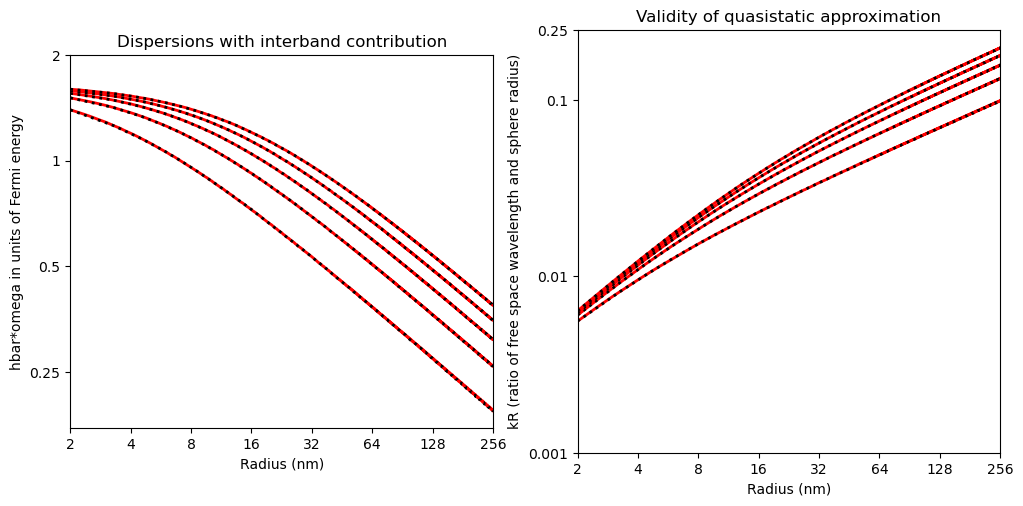

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))
for i in range(0, 5): 
    ax1.plot(log(R_range), log(non_retarded_interband_dispersions[i, :]), color="red", linewidth=2)
    ax1.plot(log(Rs_retarded), log(retarded_interband_dispersions[i, :]), linestyle="dotted", color="black", linewidth=2)
    ax2.plot(log(R_range), log(kR_non_retarded_interband[i, :]), color="red", linewidth=2)
    ax2.plot(log(Rs_retarded), log(kR_retarded_interband[i, :]), linestyle="dotted", color="black", linewidth=2)


ax1.set_xlim(log(2), log(256))
#ax1.set_ylim(log(0.125), log(2))

ax1.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax1.set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
ax1.set_aspect((log(256)-log(2))/(log(2)-log(0.125)))
ax1.set_xlabel("Radius (nm)");
ax1.set_ylabel("hbar*omega in units of Fermi energy");
ax1.set_title("Dispersions with interband contribution");

ax2.set_xlim(log(2), log(256))

ax2.set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
ax2.set_yticks(log([0.001, 0.01, 0.1, 0.25]), [0.001, 0.01, 0.1, 0.25]);
ax2.set_ylim(log(0.001), log(0.25))
ax2.set_aspect((log(256)-log(2))/(log(0.25)-log(0.001)))
ax2.set_xlabel("Radius (nm)");
ax2.set_ylabel("kR (ratio of free space wavelength and sphere radius)");
ax2.set_title("Validity of quasistatic approximation");